# 05 · The MF6.1 tyre, in depth

The tour showed the headline curves; this notebook goes deeper into the model families and —
most importantly — the **validation evidence**. Everything comes from the same `.tyr` file the
solvers consume. Equations + citations: [`docs/theory/mf61-steady-state.md`](../docs/theory/mf61-steady-state.md).

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

try:
    import ipywidgets as widgets  # noqa: F401

    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed - interactive panels are skipped "
          "(uv sync --group notebooks)")

import io

from outlap.core import Tyre, tyre_forces

tyre = Tyre.load(str(ROOT / "data" / "tires" / "pacejka_2006_205_60r15" / "car.tyr.yaml"))
print(tyre.citation)

alpha = np.linspace(np.radians(-14), np.radians(14), 300)
kappa = np.linspace(-0.25, 0.25, 300)
loads = [1500.0, 3000.0, 4500.0, 6000.0, 7500.0]

H. B. Pacejka, Tyre and Vehicle Dynamics, 2nd ed. (2006), Appendix 3, Table A3.1 (205/60R15 91V, 2.2 bar, ISO sign)


## The load family, all channels

Five loads, three channels. Watch the shapes: `Fy` saturates, `Mz` peaks *early* and collapses
— and the `Mz` peak walks forward with load (more trail under a heavier tyre):

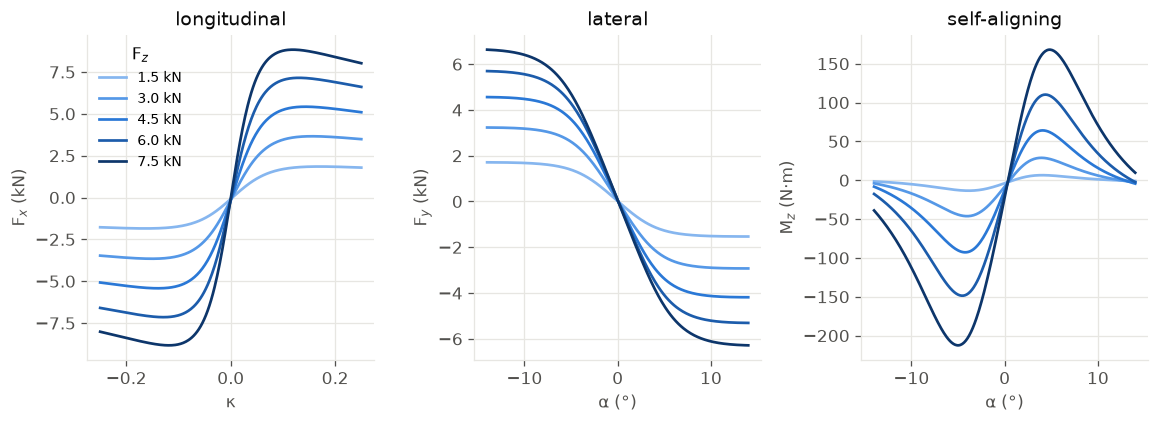

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.8))
for fz, c in zip(loads, LOADS5):
    f_k = tyre_forces(tyre, kappa=kappa, fz=fz)
    f_a = tyre_forces(tyre, alpha=alpha, fz=fz)
    axes[0].plot(kappa, f_k.fx / 1000, color=c, lw=1.7, label=f"{fz / 1000:.1f} kN")
    axes[1].plot(np.degrees(alpha), f_a.fy / 1000, color=c, lw=1.7)
    axes[2].plot(np.degrees(alpha), f_a.mz, color=c, lw=1.7)
axes[0].set_xlabel("κ"); axes[0].set_ylabel("F$_x$ (kN)"); axes[0].set_title("longitudinal")
axes[1].set_xlabel("α (°)"); axes[1].set_ylabel("F$_y$ (kN)"); axes[1].set_title("lateral")
axes[2].set_xlabel("α (°)"); axes[2].set_ylabel("M$_z$ (N·m)"); axes[2].set_title("self-aligning")
axes[0].legend(title="F$_z$", fontsize=8.5)
plt.tight_layout()
plt.show()

## The whole operating plane at once

Total force magnitude over the (κ, α) plane at nominal load — the friction ellipse is the
plateau's outline, and the ridge along each axis shows the pure-slip peaks:

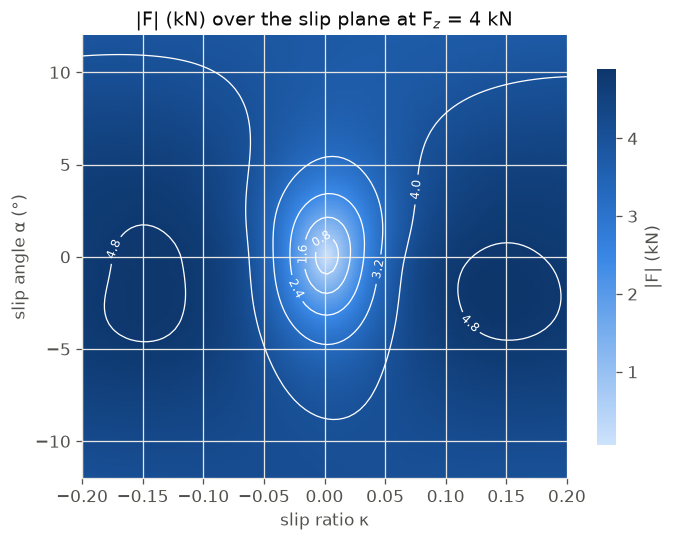

In [3]:
kk = np.linspace(-0.2, 0.2, 90)
aa = np.linspace(np.radians(-12), np.radians(12), 90)
K, A = np.meshgrid(kk, aa)
f = tyre_forces(tyre, kappa=K, alpha=A, fz=4000.0)
F = np.hypot(f.fx, f.fy) / 1000

fig, ax = plt.subplots(figsize=(6.8, 5.0))
pc = ax.pcolormesh(kk, np.degrees(aa), F, cmap=SEQ, shading="gouraud")
cs = ax.contour(kk, np.degrees(aa), F, levels=6, colors="white", linewidths=0.8)
ax.clabel(cs, fontsize=7.5, fmt="%.1f")
ax.set_xlabel("slip ratio κ")
ax.set_ylabel("slip angle α (°)")
ax.set_title("|F| (kN) over the slip plane at F$_z$ = 4 kN")
cb = fig.colorbar(pc, ax=ax, shrink=0.85, label="|F| (kN)")
cb.outline.set_visible(False)
plt.show()

## Validation, channel by channel

Every committed golden CSV (generated by an independent Magic-Formula implementation under
Octave, outputs-as-data) is re-checked here against the live model, using the **same
relative-with-floor rule as the CI gate**, over the three physics-rich channels (the CI gate
additionally holds Mx and My, which are null/near-null guards for this tyre). Four sweeps:

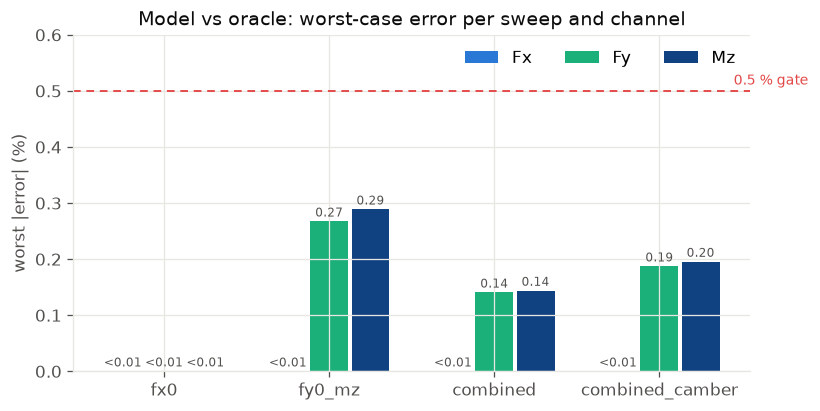

worst error anywhere: 0.289 %  (gate: 0.5 %)


In [4]:
GOLD = ROOT / "crates" / "outlap-tire" / "tests" / "golden" / "pacejka_2006_205_60r15"

def load_golden(name: str):
    lines = [ln for ln in (GOLD / name).read_text().splitlines() if not ln.startswith("#")]
    return np.genfromtxt(io.StringIO("\n".join(lines)), delimiter=",", names=True)

def worst_pct(g) -> dict[str, float]:
    ours = tyre_forces(tyre, kappa=g["kappa"], alpha=g["alpha_rad"], gamma=g["gamma_rad"],
                       fz=g["fz_n"], p=g["p_pa"], vx=g["vx_mps"])
    # Mz floor is per-load-bin max |Mz| — the exact rule of the Rust golden test.
    mz_floor = np.empty_like(g["mz_nm"])
    for fz in np.unique(g["fz_n"]):
        sel = g["fz_n"] == fz
        mz_floor[sel] = np.abs(g["mz_nm"][sel]).max()
    out = {}
    for ch, ref, floor in [
        ("Fx", g["fx_n"], 1.21 * g["fz_n"]),
        ("Fy", g["fy_n"], 0.99 * g["fz_n"]),
        ("Mz", g["mz_nm"], mz_floor),
    ]:
        model = {"Fx": ours.fx, "Fy": ours.fy, "Mz": ours.mz}[ch]
        out[ch] = float(np.max(100.0 * np.abs(model - ref) / np.maximum(np.abs(ref), floor)))
    return out

files = ["fx0.csv", "fy0_mz.csv", "combined.csv", "combined_camber.csv"]
rows = {f: worst_pct(load_golden(f)) for f in files}

fig, ax = plt.subplots(figsize=(7.6, 3.8))
width = 0.25
xpos = np.arange(len(files))
for i, (ch, c) in enumerate(zip(["Fx", "Fy", "Mz"], [BLUE, AQUA, "#104281"])):
    vals = [rows[f][ch] for f in files]
    bars = ax.bar(xpos + (i - 1) * width, vals, width * 0.92, color=c, label=ch)
    # Value labels: some errors are so small the bar is invisible — the number carries it.
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.2f}" if v >= 0.005 else "<0.01",
                    (b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5, color=INK2)
ax.axhline(0.5, color=RED, lw=1.2, ls=(0, (4, 3)))
ax.text(len(files) - 0.55, 0.505, "0.5 % gate", color=RED, fontsize=9, va="bottom")
ax.set_xticks(xpos, [f.replace(".csv", "") for f in files])
ax.set_ylabel("worst |error| (%)")
ax.set_title("Model vs oracle: worst-case error per sweep and channel")
ax.legend(ncols=3)
ax.set_ylim(0, 0.6)
plt.show()

worst = max(v for r in rows.values() for v in r.values())
assert worst <= 0.5, "the 0.5% gate must hold"
print(f"worst error anywhere: {worst:.3f} %  (gate: 0.5 %)")

> **▶ Interactive.** The next cell is live only in a running Jupyter (`uv sync --group notebooks`,
> then `uv run --with jupyterlab jupyter lab`). On GitHub you're seeing its static twin above.

interactive(children=(FloatSlider(value=4000.0, description='Fz (N)', max=8000.0, min=1000.0, step=250.0), Flo…

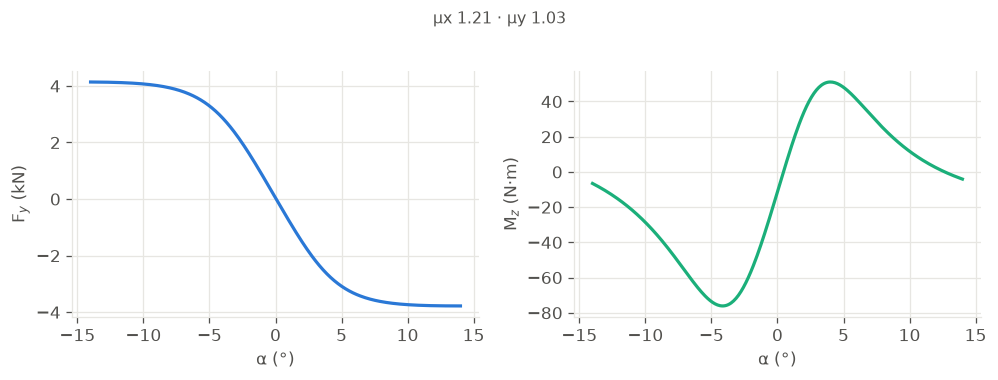

In [5]:
if HAVE_WIDGETS:

    @widgets.interact(
        fz=widgets.FloatSlider(min=1000, max=8000, step=250, value=4000, description="Fz (N)"),
        camber=widgets.FloatSlider(min=-8, max=8, step=1, value=0, description="γ (°)"),
    )
    def tyre_lab(fz: float, camber: float) -> None:
        f = tyre_forces(tyre, alpha=alpha, fz=fz, gamma=np.radians(camber))
        fig, (a, b) = plt.subplots(1, 2, figsize=(8.8, 3.2))
        a.plot(np.degrees(alpha), f.fy / 1000, color=BLUE)
        a.set_xlabel("α (°)"); a.set_ylabel("F$_y$ (kN)")
        b.plot(np.degrees(alpha), f.mz, color=AQUA)
        b.set_xlabel("α (°)"); b.set_ylabel("M$_z$ (N·m)")
        mux, muy = tyre.peak_mu(fz, tyre.p_cold)
        fig.suptitle(f"μx {mux:.2f} · μy {muy:.2f}", y=1.02, color=INK2, fontsize=10)
        plt.tight_layout(); plt.show()

    tyre_lab(4000.0, 0.0)  # direct call: a real error here must fail CI

**Next:** [06 · powertrains & the PDT importer](06_powertrain_pdt.ipynb) — where the driving
force comes from.